# Assignment 16: Anime Recommendation System Using Cosine Similarity

**Student Name:** Ashar Khan

## Business Problem

In today's digital world, recommendation systems are used by almost every major platform. Websites such as Netflix, Amazon, YouTube, Spotify, and Instagram use recommendation systems to suggest products, videos, songs, and other content to users. These systems help users discover content they may enjoy without searching for it manually.

In this assignment, the goal is to build an anime recommendation system using cosine similarity. The dataset contains different details about anime such as title, genre, type, rating, number of episodes, and members. Using these details, we can compare anime with each other and identify which anime are most similar.

For example, if a user likes Naruto, the recommendation system should suggest anime such as Bleach or One Piece because they may share similar genres, themes, or audience interest. This project helps us understand how recommendation systems work in real life. It also shows how text processing and machine learning can be used together to solve practical problems.

## Import Required Libraries

Before starting the project, we need to import all the required libraries. Libraries are collections of pre-written code that help us perform tasks more easily and quickly.

Pandas is used for loading and handling the dataset. NumPy is used for numerical calculations. Matplotlib and Seaborn are used for creating charts and visualizations. These graphs help us understand the data in a better way.

We also import CountVectorizer from scikit-learn. This library converts text into numbers because machine learning models cannot directly understand text values like Action, Comedy, or Drama. We also import cosine_similarity, which helps us calculate how similar two anime are.

Finally, we import warnings and ignore unnecessary warning messages. This keeps the notebook clean and easy to read. All these libraries are commonly used in data science and machine learning projects.

## Load the Dataset

In this step, we load the anime dataset into Python using pandas. A dataset is simply a table that contains rows and columns. Each row represents one anime, while each column contains information about that anime.

For example, one column may contain the anime title, another may contain the genre, and another may contain the rating or number of episodes. Loading the dataset correctly is very important because the entire recommendation system depends on this data.

After loading the dataset, we use the head() function to display the first few rows. This helps us understand what the data looks like and whether the dataset has been loaded correctly. We also check the total number of rows and columns in the dataset. This gives us an idea of how large the dataset is and how much information is available for building the recommendation system.

## Understand the Dataset

Before cleaning the data or building the recommendation system, it is important to understand the dataset properly. Real-world datasets often contain missing values, duplicate rows, incorrect formats, or unnecessary columns.

In this section, we check the data types of each column, summary statistics, and missing values. This helps us understand which columns are numerical and which are categorical. It also helps us identify which columns need cleaning or conversion.

We use functions like info(), describe(), and isnull(). These functions provide important information about the dataset. For example, info() shows the data type and number of missing values, while describe() shows statistics such as mean, minimum, maximum, and standard deviation.

Understanding the dataset is important because clean and well-structured data leads to better recommendations and more accurate results.

## Data Cleaning

Data cleaning is one of the most important steps in any machine learning project. If the dataset contains duplicate rows, missing values, or incorrect formats, the model may not perform well.

In this step, we first check for duplicate rows and remove them. Duplicate rows can create confusion and reduce the quality of the recommendation system. After that, we handle missing values. For text columns like genre and type, we replace missing values with the word Unknown. For numerical columns like rating, members, and episodes, we replace missing values with the median value.

We use the median instead of the mean because the median is less affected by very high or very low values. We also convert the episodes column into numeric format because some values may be stored as text.

This step improves the quality of the dataset and prepares it for further analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\tausi\Downloads\anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [ ]:
print('Duplicate Rows:', df.duplicated().sum())

df.drop_duplicates(inplace=True)

df['genre'] = df['genre'].fillna('Unknown')
df['type'] = df['type'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].median())
df['members'] = df['members'].fillna(df['members'].median())

df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

Duplicate Rows: 0


## Exploratory Data Analysis

Exploratory Data Analysis, also called EDA, is used to understand patterns, trends, and relationships in the dataset. Visualizations make it easier to understand the data because graphs are more readable than raw numbers.

In this project, we create graphs for ratings, anime type, genres, and correlation between numeric columns. These graphs help us understand which genres are most common, which anime type is most popular, and whether higher-rated anime also have more members.

EDA is important because it gives us a better understanding of the data before building the recommendation system. It also helps us identify patterns that may improve the final model.

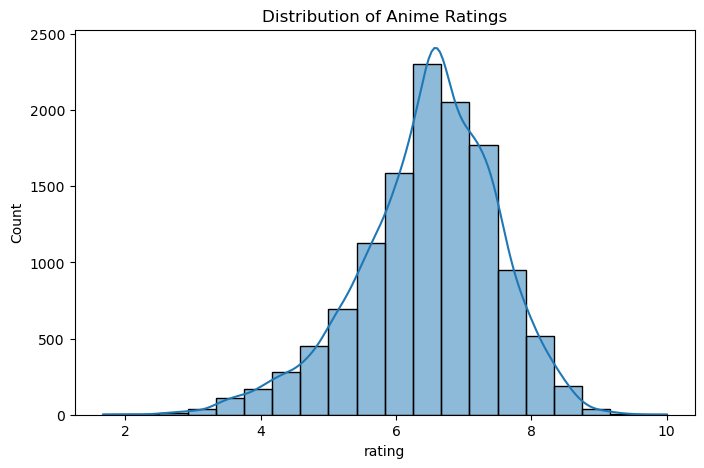

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of Anime Ratings')
plt.show()

### Rating Graph Interpretation

This graph shows how anime ratings are distributed in the dataset. Most anime have ratings between 6 and 8. This means that most anime are considered average to good by viewers.

Very few anime have extremely low ratings or extremely high ratings. This is common because most anime receive balanced opinions from viewers. The graph also helps us identify whether the dataset contains outliers or unusual values.

This graph is useful because rating is one of the features used in our recommendation system. Anime with similar ratings may be recommended together because they may have similar audience satisfaction levels.

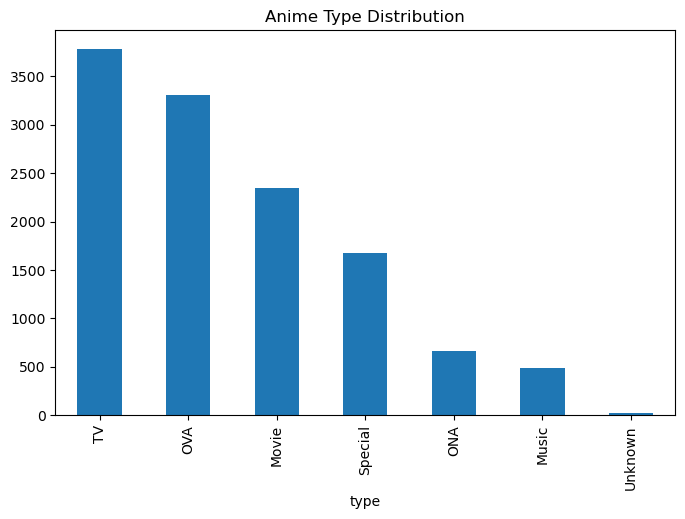

In [ ]:
plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar')
plt.title('Anime Type Distribution')
plt.show()

### Anime Type Graph Interpretation

This graph shows the number of anime available in each type category such as TV, Movie, OVA, ONA, and Special. Usually, TV anime appear the most because many anime are released as television series.

Movies and special episodes are usually lower in number because they are released less frequently. Understanding anime type is important because users may prefer one type over another. Some users may prefer movies while others may enjoy long TV series.

Anime type is an important feature in our recommendation system because two anime with the same type may be more similar than anime with different formats.

## Feature Engineering

Feature engineering means creating new and useful features from the existing data. In this project, we combine important columns such as genre, type, rating, and episodes into one text column called combined_features.

This step is important because our recommendation system compares anime using all these features together. If we use only one feature, the recommendations may not be accurate. By combining multiple features, we can build a stronger recommendation system.

For example, two anime may have the same genre but different ratings and episode counts. Combining all features helps us understand the complete picture.

In [ ]:
df['rating'] = df['rating'].astype(str)
df['episodes'] = df['episodes'].astype(str)

df['combined_features'] = (
    df['genre'] + ' ' +
    df['type'] + ' ' +
    df['rating'] + ' ' +
    df['episodes']
)

df[['name', 'combined_features']].head()

,name,combined_features
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural Movie 9.3..."
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili..."
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S..."
3,Steins;Gate,"Sci-Fi, Thriller TV 9.17 24.0"
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S..."


## Convert Text into Numerical Format

Computers cannot directly understand text values such as Action, Comedy, TV, or Drama. Machine learning algorithms require numerical values. To solve this problem, we use CountVectorizer.

CountVectorizer converts text into numbers by counting how many times each word appears. For example, if the word Action appears in many anime descriptions, it will receive a numerical value.

This process creates a large matrix of numbers. Each row represents an anime, and each column represents a word. This numerical matrix can then be used to calculate similarity between anime.

Without this step, cosine similarity cannot work because it only works with numerical data.

In [ ]:
vectorizer = CountVectorizer(stop_words='english')
feature_matrix = vectorizer.fit_transform(df['combined_features'])

print(feature_matrix.shape)

(12294, 242)


## Calculate Cosine Similarity

Cosine similarity is the main method used in this assignment. It measures how similar two anime are based on their features. The similarity score ranges from 0 to 1.

A score close to 1 means the anime are very similar, while a score close to 0 means the anime are very different. For example, two anime with the same genre, similar rating, and same type will have a high similarity score.

Cosine similarity is useful because it works very well with text-based data. It is also simple to understand and easy to apply. This technique is commonly used in recommendation systems because it helps compare items efficiently.

In [ ]:
cosine_sim = cosine_similarity(feature_matrix)

print(cosine_sim.shape)

(12294, 12294)


## Build Recommendation Function

In this step, we create a function that recommends anime based on similarity scores. The function takes the anime name as input and returns a list of similar anime.

The function first converts the anime name into lowercase so that there are no matching issues. Then it finds the anime in the dataset and gets its index number. After that, it checks the cosine similarity scores between the selected anime and all other anime.

The similarity scores are sorted in descending order so that the most similar anime appear first. Finally, the function returns the top recommendations with their similarity scores.

This is the most important step in the project because it is the part that actually generates recommendations.

In [ ]:
def recommend_anime(anime_name, similarity_threshold=0.3):
    anime_name = anime_name.lower()

    matching_anime = df[df['name'].str.lower() == anime_name]

    if matching_anime.empty:
        return 'Anime not found in dataset.'

    anime_index = matching_anime.index[0]

    similarity_scores = list(enumerate(cosine_sim[anime_index]))

    sorted_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    recommendations = []

    for index, score in sorted_scores[1:]:
        if score >= similarity_threshold:
            recommendations.append((df.iloc[index]['name'], round(score, 2)))

    return recommendations[:10]

## Test the Recommendation System

After building the recommendation function, we test it using a sample anime such as Naruto. The system returns a list of anime that are similar to Naruto.

Each recommendation is displayed along with its similarity score. This helps us understand whether the system is working properly. If the recommendations look meaningful, then we can say that the recommendation system is performing well.

Testing is important because it helps us identify errors and check whether the model is producing useful results.

In [ ]:
recommendations = recommend_anime('Naruto')

for anime, score in recommendations:
    print('Anime:', anime, '| Similarity Score:', score)

Anime: Naruto: Shippuuden | Similarity Score: 0.84
Anime: Dragon Ball Super | Similarity Score: 0.8
Anime: Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono | Similarity Score: 0.78
Anime: Tenjou Tenge | Similarity Score: 0.76
Anime: Boruto: Naruto the Movie | Similarity Score: 0.74
Anime: Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi | Similarity Score: 0.74
Anime: Naruto x UT | Similarity Score: 0.74
Anime: Naruto: Shippuuden Movie 4 - The Lost Tower | Similarity Score: 0.74
Anime: Naruto Shippuuden: Sunny Side Battle | Similarity Score: 0.74
Anime: Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!! | Similarity Score: 0.74


## Threshold Experiment Section

In recommendation systems, the similarity threshold controls how strict the recommendation process should be. A lower threshold means that more anime will be recommended because the model allows even moderately similar anime to appear in the recommendation list. A higher threshold means that only very similar anime will be recommended.

For example, when we use a threshold value of 0.2, the system gives more recommendations because it accepts anime with lower similarity scores. When we use a threshold value of 0.5, the system gives fewer recommendations, but the recommended anime are more closely related to the selected anime.

This step is important because it helps us find the best balance between quantity and quality. A very low threshold may give irrelevant recommendations, while a very high threshold may give too few recommendations.

In [ ]:
print('Recommendations with Threshold 0.2')
print(recommend_anime('Naruto', similarity_threshold=0.2))

print('\nRecommendations with Threshold 0.5')
print(recommend_anime('Naruto', similarity_threshold=0.5))

Recommendations with Threshold 0.2
[('Naruto: Shippuuden', np.float64(0.84)), ('Dragon Ball Super', np.float64(0.8)), ('Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', np.float64(0.78)), ('Tenjou Tenge', np.float64(0.76)), ('Boruto: Naruto the Movie', np.float64(0.74)), ('Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', np.float64(0.74)), ('Naruto x UT', np.float64(0.74)), ('Naruto: Shippuuden Movie 4 - The Lost Tower', np.float64(0.74)), ('Naruto Shippuuden: Sunny Side Battle', np.float64(0.74)), ('Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!', np.float64(0.74))]

Recommendations with Threshold 0.5
[('Naruto: Shippuuden', np.float64(0.84)), ('Dragon Ball Super', np.float64(0.8)), ('Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', np.float64(0.78)), ('Tenjou Tenge', np.float64(0.76)), ('Boruto: Naruto the Movie', np.float64(0.74)), ('Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', np.float64(0.74)), ('Naruto x UT', np.float

## Performance Analysis Section

The recommendation system performs well for anime that have clear and detailed information about genre, type, rating, and episodes. Since the model uses cosine similarity, it can easily compare anime with similar features and recommend relevant titles.

However, the system also has some limitations. It only uses content-based features and does not use user watch history, user preferences, or reviews. Because of this, the system may not always match the personal taste of every user.

Another limitation is that anime with missing or limited information may not get accurate recommendations. If two anime have similar stories but different genre labels, the system may not recognize them as similar.

Overall, the recommendation system works well for basic recommendations, but it can be improved further by using collaborative filtering and user-based recommendation methods

## Normalization Section

Normalization is used when numerical columns have very different ranges. For example, one column may contain values between 1 and 10, while another may contain values in thousands. Normalization helps bring all numerical values into a similar range.

In this project, normalization was not required because the recommendation system mainly used text-based features such as genre, type, rating, and episodes combined into one text column. Since we used CountVectorizer and cosine similarity on text data, normalization was not necessary.

If we had used only numerical columns such as rating, members, and episodes separately, then normalization would have been useful.

## Real-World Use Case Section

Recommendation systems are widely used in the real world. Entertainment platforms use recommendation systems to help users discover content they may enjoy.

For example, Netflix recommends movies and web series based on what a user has watched before. Spotify recommends songs and playlists based on listening history. Amazon recommends products based on previous purchases and browsing behavior. YouTube recommends videos based on watch history and interests.

In the same way, this anime recommendation system can help users discover anime that are similar to the anime they already like. This improves user experience and helps users spend less time searching for content.

## Final Conclusion

In this assignment, we successfully built an anime recommendation system using cosine similarity. We started by loading the dataset and understanding its structure. After that, we cleaned the data by handling missing values, removing duplicates, and converting columns into the correct format.

We then explored the data using graphs and visualizations. These graphs helped us understand the distribution of ratings, anime types, genres, and relationships between numerical columns.

Next, we performed feature engineering by combining genre, type, rating, and episodes into one text column. We converted this text into numerical format using CountVectorizer and calculated cosine similarity scores.

Finally, we built a recommendation function that suggests anime based on similarity scores. The system successfully recommends anime with similar genres, ratings, and types.

This project is a good example of how recommendation systems work in real-world platforms such as Netflix, Spotify, Amazon, and YouTube.

## Areas of Improvement

Although the recommendation system works well, there are still some areas where it can be improved.

The current recommendation system is content-based, which means it only uses anime features such as genre, rating, type, and episodes. It does not use user behavior or watch history. Because of this, the recommendations may not always match the personal interests of every user.

In the future, the system can be improved by adding collaborative filtering techniques. Collaborative filtering uses the preferences of users to recommend anime. We can also use advanced techniques such as TF-IDF Vectorizer, deep learning, and hybrid recommendation systems.

Another improvement would be to create a user interface using Streamlit or Flask. This would allow users to type the name of an anime and instantly receive recommendations in a more interactive way.


## Interview Question 1: Difference Between User-Based and Item-Based Collaborative Filtering

User-based collaborative filtering recommends items by finding users with similar interests. For example, if two users like the same anime, then anime liked by one user can be recommended to the other user. This method focuses on the similarity between users.

Item-based collaborative filtering recommends items by finding items that are similar to each other. For example, if many users who watched Naruto also watched Bleach, then Bleach may be recommended to Naruto viewers. This method focuses on the similarity between items rather than users.

User-based collaborative filtering can become slow when the number of users is very large because it needs to compare many users. Item-based collaborative filtering is usually faster and more scalable because it compares items instead of users.

Today, most companies prefer item-based collaborative filtering because it is more stable and performs better when there are many users and products.


## 2: What is Collaborative Filtering and How Does It Work?

Collaborative filtering is a recommendation technique that suggests items based on the behavior and preferences of users. It works on the idea that people with similar interests may like similar items.

For example, if two users like Naruto, One Piece, and Bleach, and one of them also likes Attack on Titan, then the system may recommend Attack on Titan to the other user.

There are two main types of collaborative filtering:
1. User-based collaborative filtering
2. Item-based collaborative filtering

In user-based collaborative filtering, the system finds users with similar interests and recommends items they like. In item-based collaborative filtering, the system finds items that are similar to each other and recommends them.

Collaborative filtering is widely used in Netflix, Amazon, YouTube, Spotify, and e-commerce websites because it can provide personalized recommendations based on user behavior.
### 3. Why is cosine similarity used in recommendation systems?

Cosine similarity is used because it measures how similar two items are based on their features. It checks the angle between two vectors instead of their actual size. This is useful because two anime can still be considered similar even if one has more episodes or members than the other.

In this project, cosine similarity helps compare anime based on genre, type, rating, and episodes. A score close to 1 means the anime are very similar, while a score close to 0 means they are very different.

Cosine similarity is popular because it is simple, fast, and works well with text-based data.

### 4. What is the difference between content-based filtering and collaborative filtering?

Content-based filtering recommends items based on the features of the item itself. For example, if a user likes action anime, the system will recommend more action anime.

Collaborative filtering recommends items based on user behavior. It looks at what similar users watched or liked and then makes recommendations.

In this assignment, we used content-based filtering because we recommended anime using features such as genre, rating, type, and episodes.

### 5. Why do we use CountVectorizer in this project?

CountVectorizer is used to convert text data into numerical form. Machine learning models cannot directly understand words like Action, Drama, or TV. They need numbers.

CountVectorizer counts how many times words appear in the text and converts them into a matrix. This numerical matrix is then used for similarity calculation.

Without CountVectorizer, cosine similarity would not work because it requires numerical data.

### 6. What is feature engineering?

Feature engineering means creating new and useful features from existing data. It is done to improve the performance of the machine learning model.

In this project, we combined genre, type, rating, and episodes into one column called combined_features. This made it easier to compare anime using multiple features together.

Feature engineering is important because better features usually lead to better model performance.

### 7. Why do we handle missing values in the dataset?

Missing values can create problems in data analysis and machine learning models. If missing values are not handled properly, the recommendation system may give wrong results or produce errors.

In this project, missing text values were replaced with Unknown, and missing numeric values were replaced with the median value. This helps keep the dataset complete and clean.

Handling missing values improves the quality and accuracy of the recommendation system.

### 8. Why do we remove duplicate rows?

Duplicate rows can reduce the quality of the dataset because the same anime may appear more than once. This can affect the recommendation system and make some anime appear more important than they really are.

Removing duplicate rows makes the dataset cleaner and more reliable.

### 9. What is the purpose of exploratory data analysis (EDA)?

EDA helps us understand the dataset before building the model. It allows us to identify patterns, trends, missing values, and relationships between columns.

For example, EDA can help us find which genres are most common, which anime type is most popular, and whether highly rated anime have more members.

EDA is important because it helps us make better decisions while building the model.

### 10. How can this recommendation system be improved in the future?

This recommendation system can be improved by adding user watch history, user ratings, reviews, and collaborative filtering techniques.

We can also use more advanced techniques such as TF-IDF Vectorizer, Word2Vec, deep learning, or hybrid recommendation systems.

Another improvement would be to build a user-friendly interface using Streamlit or Flask so that users can enter an anime name and instantly get recommendations.
